Import Libraries

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
    )

np.random.seed(42)


Generate the Dataset.

In [56]:
n = 1000

soil_moisture = np.random.uniform(10, 60, n)
temperature = np.random.uniform(20, 40, n)
rain_probability = np.random.uniform(0, 100, n)
humidity = np.random.uniform(30, 95, n)
wind_speed = np.random.uniform(0, 30, n)

crop_stage = np.random.choice(
    ["vegetative", "flowering", "fruiting"],
    n
)

# Create a realistic irrigation need score
score = (
    (35 - soil_moisture) * 0.10
    + (temperature - 25) * 0.08
    - rain_probability * 0.025
    + (50 - humidity) * 0.015
    + wind_speed * 0.015
)

# Flowering and fruiting crops generally have higher water demand
score += np.where(
    crop_stage == "flowering", 0.4, 0
)

score += np.where(
    crop_stage == "fruiting", 0.5, 0
)

# Add random uncertainty
score += np.random.normal(0, 0.5, n)

irrigation_needed = (score > 1.0).astype(int)

data = pd.DataFrame({
    "soil_moisture": soil_moisture,
    "temperature": temperature,
    "rain_probability": rain_probability,
    "humidity": humidity,
    "wind_speed": wind_speed,
    "crop_stage": crop_stage,
    "irrigation_needed": irrigation_needed
})

data.head()

,soil_moisture,temperature,rain_probability,humidity,wind_speed,crop_stage,irrigation_needed
0,28.727006,23.702659,26.170568,73.725695,17.159876,fruiting,0
1,57.535715,30.838019,24.697880,81.784291,24.162970,fruiting,0
2,46.599697,37.458917,90.625458,46.280413,22.804828,fruiting,0
3,39.932924,34.644498,24.954620,70.616816,4.616997,flowering,0
4,17.800932,36.131223,27.194973,67.163489,4.477484,fruiting,1


Introduce Missing Information.

In [57]:
data_incomplete = data.copy()

missing_columns = [
    "soil_moisture",
    "temperature",
    "rain_probability",
    "humidity"
]

for column in missing_columns:
    mask = np.random.rand(len(data_incomplete)) < 0.10
    data_incomplete.loc[mask, column] = np.nan

print("Missing values:")
print(data_incomplete.isnull().sum())

Missing values:
soil_moisture        111
temperature           99
rain_probability      92
humidity              96
wind_speed             0
crop_stage             0
irrigation_needed      0
dtype: int64


Prepare the Data.

In [58]:
# Separate the input variables from the target.

X = data_incomplete.drop("irrigation_needed", axis=1)
y = data_incomplete["irrigation_needed"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
            test_size=0.20,
                random_state=42,
                    stratify=y
                    )


Handle Missing Data.

In [59]:
# Numerical values will be replaced using the median.
# Categorical information will be replaced using the most frequent value.
# This allows the model to continue operating even when some information is unavailable.

numeric_features = [
    "soil_moisture",
    "temperature",
    "rain_probability",
    "humidity",
    "wind_speed"
]

categorical_features = ["crop_stage"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

Build the AI Model.

In [60]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['soil_moisture',
                                                   'temperature',
                                                   'rain_probability',
                                                   'humidity', 'wind_speed']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['crop_stage'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

Test the AI.

In [61]:
# The exact accuracy will vary slightly depending on the generated data.
predictions = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print(f"Model Accuracy: {accuracy:.2%}")

print("\nClassification Report:")
print(classification_report(y_test, predictions))

Model Accuracy: 92.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95       156
           1       0.94      0.68      0.79        44

    accuracy                           0.92       200
   macro avg       0.93      0.83      0.87       200
weighted avg       0.92      0.92      0.92       200



Confusion Matrix.

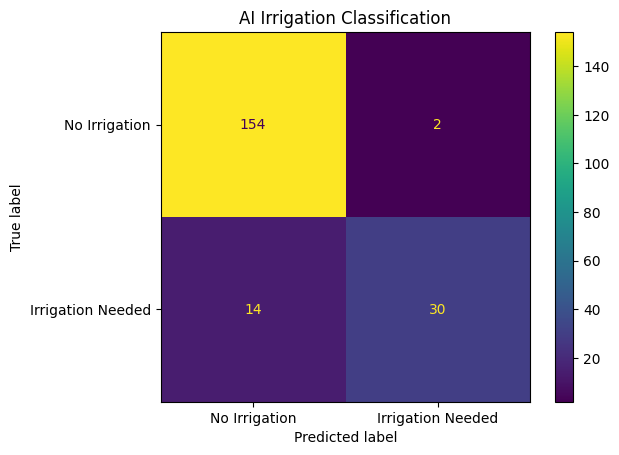

In [62]:
# This helps us see where the AI makes correct and incorrect decisions.
cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Irrigation", "Irrigation Needed"]
    )
disp.plot()
plt.title("AI Irrigation Classification")
plt.show()

** Probabilities Instead of Yes/No to Irrigation**

Interpretation:

0.94 → very strong evidence that irrigation is needed

0.67 → reasonably strong evidence

0.51 → uncertain

0.12 → strong evidence that irrigation is unnecessary


In [63]:
probabilities = pipeline.predict_proba(X_test)[:, 1]

results = X_test.copy()

results["actual"] = y_test.values
results["irrigation_probability"] = probabilities

results.head(10)

,soil_moisture,temperature,rain_probability,humidity,wind_speed,crop_stage,actual,irrigation_probability
904,31.071228,34.914676,52.251018,84.873801,27.781787,vegetative,0,0.035
910,39.514747,26.112084,23.041666,32.552512,26.534362,flowering,0,0.175
251,29.254886,29.630447,NaN,37.500652,1.861103,fruiting,0,0.170
21,16.974693,25.946980,56.016818,NaN,7.215948,fruiting,0,0.625
256,56.807739,24.010495,51.744635,74.984787,29.932482,fruiting,0,0.040
716,51.530970,21.155611,NaN,52.098171,17.881503,flowering,0,0.005
320,37.461333,24.942065,90.761100,65.647246,17.419357,vegetative,0,0.005
849,39.769251,32.916216,35.857846,34.449279,3.260476,vegetative,0,0.135
825,55.992781,30.606043,84.804209,35.504742,4.796393,flowering,0,0.040
155,22.102764,35.054333,23.987411,72.205951,0.386924,flowering,1,0.660


Build the Decision Engine.

In [64]:
# The AI must translate the probability into an action.

def recommend_action(probability):

    if probability >= 0.70:
        return "IRRIGATE"

    elif probability >= 0.40:
        return "IRRIGATE LIGHTLY"

    else:
        return "WAIT"

# Assuming 'results' DataFrame and 'irrigation_probability' column exist from previous steps
# For demonstration purposes, let's create a dummy 'results' if it doesn't exist
try:
    results['recommendation'] = (
        results['irrigation_probability']
        .apply(recommend_action)
    )
except NameError:
    # This block will execute if 'results' DataFrame is not yet defined
    # For a full run, ensure 'results' is defined from previous cells
    print("Warning: 'results' DataFrame not found. Creating a dummy for demonstration.")
    dummy_probabilities = pd.Series([0.8, 0.5, 0.2, 0.75, 0.35, 0.4, 0.9])
    results = pd.DataFrame({
        'irrigation_probability': dummy_probabilities
    })
    results['recommendation'] = (
        results['irrigation_probability']
        .apply(recommend_action)
    )

print(results[['irrigation_probability', 'recommendation']].head(15))


     irrigation_probability    recommendation
904                   0.035              WAIT
910                   0.175              WAIT
251                   0.170              WAIT
21                    0.625  IRRIGATE LIGHTLY
256                   0.040              WAIT
716                   0.005              WAIT
320                   0.005              WAIT
849                   0.135              WAIT
825                   0.040              WAIT
155                   0.660  IRRIGATE LIGHTLY
48                    0.050              WAIT
613                   0.285              WAIT
507                   0.050              WAIT
499                   0.045              WAIT
118                   0.015              WAIT


Expected Cost Decision Making.

There are two possible environmental states:

1. The crop needs water.


2. The crop does not need water.


And there are three actions:

Irrigate

Irrigate lightly

Wait


We can assign approximate costs.


In [65]:
def expected_cost(probability, action):

    # Cost assumptions
    if action == "IRRIGATE":
        cost_if_needed = 1
        cost_if_not_needed = 5

    elif action == "IRRIGATE LIGHTLY":
        cost_if_needed = 2
        cost_if_not_needed = 2

    else:  # WAIT
        cost_if_needed = 8
        cost_if_not_needed = 1

    expected = (
        probability * cost_if_needed
        + (1 - probability) * cost_if_not_needed
    )

    return expected


def optimal_action(probability):

    actions = [
        "IRRIGATE",
        "IRRIGATE LIGHTLY",
        "WAIT"
    ]

    costs = {
        action: expected_cost(probability, action)
        for action in actions
    }

    best_action = min(costs, key=costs.get)

    return best_action, costs

Test the Decision Engine.


The important principle is:

The AI chooses the action with the lowest expected cost based on the information currently available.

This is the connection between machine learning and decision theory.


In [66]:
for probability in [0.1, 0.3, 0.5, 0.7, 0.9]:
    action, costs = optimal_action(probability)
    print(f"\nProbability: {probability:.0%}")
    print(f"Expected Costs: {costs}")
    print(f"Recommended Action: {action}")


Probability: 10%
Expected Costs: {'IRRIGATE': 4.6, 'IRRIGATE LIGHTLY': 2.0, 'WAIT': 1.7000000000000002}
Recommended Action: WAIT

Probability: 30%
Expected Costs: {'IRRIGATE': 3.8, 'IRRIGATE LIGHTLY': 2.0, 'WAIT': 3.0999999999999996}
Recommended Action: IRRIGATE LIGHTLY

Probability: 50%
Expected Costs: {'IRRIGATE': 3.0, 'IRRIGATE LIGHTLY': 2.0, 'WAIT': 4.5}
Recommended Action: IRRIGATE LIGHTLY

Probability: 70%
Expected Costs: {'IRRIGATE': 2.2, 'IRRIGATE LIGHTLY': 2.0, 'WAIT': 5.8999999999999995}
Recommended Action: IRRIGATE LIGHTLY

Probability: 90%
Expected Costs: {'IRRIGATE': 1.4, 'IRRIGATE LIGHTLY': 2.0, 'WAIT': 7.3}
Recommended Action: IRRIGATE


Real Time Decision Example.

In [67]:
import pandas as pd

# Now we simulate a farmer using the system.

current_conditions = pd.DataFrame({
    "soil_moisture": [20],
    "temperature": [36],
    "rain_probability": [15],
    "humidity": [45],
    "wind_speed": [18],
    "crop_stage": ["flowering"]
})

probability = pipeline.predict_proba(
    current_conditions
)[0, 1]

action, costs = optimal_action(probability)

print("CURRENT FARM CONDITIONS")
print("------------------------")
print(current_conditions)

print(f"\nProbability irrigation is needed: {probability:.1%}")
print(f"Recommended action: {action}")
print(f"Expected costs: {costs}")

CURRENT FARM CONDITIONS
------------------------
   soil_moisture  temperature  rain_probability  humidity  wind_speed  \
0             20           36                15        45          18   

  crop_stage  
0  flowering  

Probability irrigation is needed: 88.5%
Recommended action: IRRIGATE
Expected costs: {'IRRIGATE': np.float64(1.46), 'IRRIGATE LIGHTLY': np.float64(2.0), 'WAIT': np.float64(7.195)}


Changing Information

This is the most important demonstration of the project.

Initially:

Soil moisture       = 20%
Temperature         = 36°C
Rain probability    = 15%

The AI may recommend:

> IRRIGATE



But suppose a new weather update arrives.
The recommendation can change because the information has changed.

For example:

BEFORE WEATHER UPDATE

Irrigation probability: 94%
Recommendation: IRRIGATE


AFTER WEATHER UPDATE

Rain probability: 85%
Irrigation probability: 30%
Recommendation: WAIT

This demonstrates adaptive AI decision-making.

In [68]:
updated_conditions = current_conditions.copy()

updated_conditions["rain_probability"] = 85

new_probability = pipeline.predict_proba(
    updated_conditions
)[0, 1]

new_action, new_costs = optimal_action(
    new_probability
)

print("UPDATED WEATHER INFORMATION")
print("---------------------------")
print(f"Rain probability: 85%")
print(
    f"New irrigation probability: "
    f"{new_probability:.1%}"
)
print(f"New recommendation: {new_action}")

UPDATED WEATHER INFORMATION
---------------------------
Rain probability: 85%
New irrigation probability: 44.0%
New recommendation: IRRIGATE LIGHTLY


Visualise Decision Behaviour.

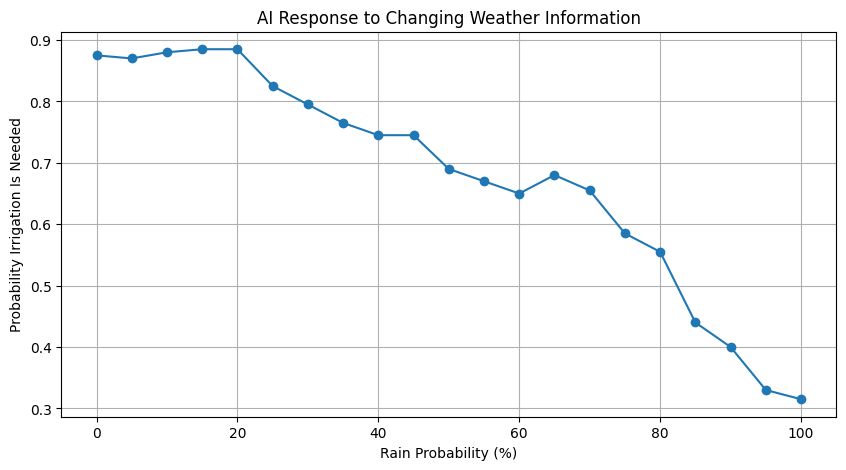

In [69]:
rain_values = np.arange(0, 101, 5)
probabilities = []

for rain in rain_values:
    scenario = pd.DataFrame({
        "soil_moisture": [20],
        "temperature": [36],
        "rain_probability": [rain],
        "humidity": [45],
        "wind_speed": [18],
        "crop_stage": ["flowering"]
    })

    p = pipeline.predict_proba(scenario)[0, 1]
    probabilities.append(p)

plt.figure(figsize=(10, 5))

plt.plot(
    rain_values,
    probabilities,
    marker="o"
)

plt.xlabel("Rain Probability (%)")
plt.ylabel("Probability Irrigation Is Needed")
plt.title("AI Response to Changing Weather Information")
plt.grid(True)

plt.show()

Simulate a Changing Environment.

In [70]:
# We can go one step further and simulate the AI operating throughout a day.

hours = list(range(6, 19))

rain_forecast = [
    10, 10, 15, 20, 25, 30, 45,
    55, 65, 70, 75, 80, 85
]

decisions = []
probabilities = []

for hour, rain in zip(hours, rain_forecast):

    scenario = pd.DataFrame({
        "soil_moisture": [20],
        "temperature": [35],
        "rain_probability": [rain],
        "humidity": [50],
        "wind_speed": [15],
        "crop_stage": ["flowering"]
    })

    probability = pipeline.predict_proba(
        scenario
    )[0, 1]

    action, _ = optimal_action(probability)

    probabilities.append(probability)
    decisions.append(action)

daily_results = pd.DataFrame({
    "hour": hours,
    "rain_probability": rain_forecast,
    "irrigation_probability": probabilities,
    "recommendation": decisions
})

print(daily_results)

    hour  rain_probability  irrigation_probability    recommendation
0      6                10                   0.880          IRRIGATE
1      7                10                   0.880          IRRIGATE
2      8                15                   0.885          IRRIGATE
3      9                20                   0.895          IRRIGATE
4     10                25                   0.795          IRRIGATE
5     11                30                   0.765          IRRIGATE
6     12                45                   0.725  IRRIGATE LIGHTLY
7     13                55                   0.630  IRRIGATE LIGHTLY
8     14                65                   0.615  IRRIGATE LIGHTLY
9     15                70                   0.575  IRRIGATE LIGHTLY
10    16                75                   0.515  IRRIGATE LIGHTLY
11    17                80                   0.495  IRRIGATE LIGHTLY
12    18                85                   0.390  IRRIGATE LIGHTLY


Visualise the Daily Decision.

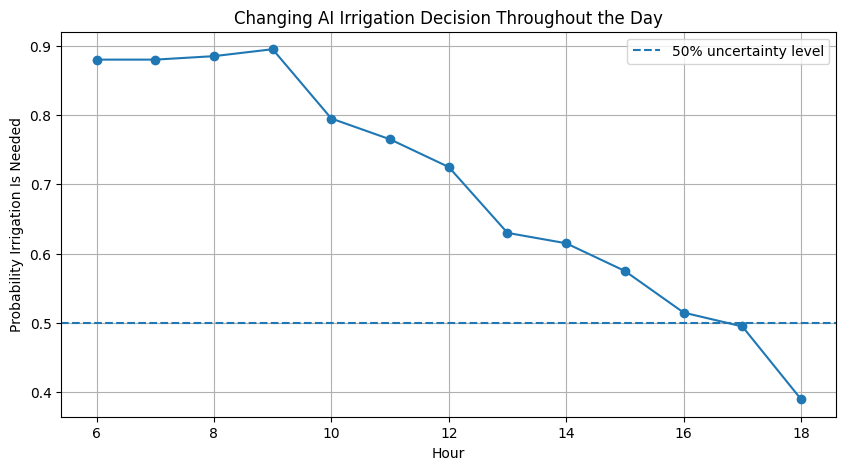

In [71]:
plt.figure(figsize=(10, 5))

plt.plot(
    daily_results["hour"],
    daily_results["irrigation_probability"],
    marker="o"
)

plt.axhline(
    0.5,
    linestyle="--",
    label="50% uncertainty level"
)

plt.xlabel("Hour")
plt.ylabel("Probability Irrigation Is Needed")
plt.title("Changing AI Irrigation Decision Throughout the Day")

plt.legend()
plt.grid(True)
plt.show()